# This notebook is used to generate figures for the presentation on ExactBO

## 1 - BO vs ExactBO Domain Management

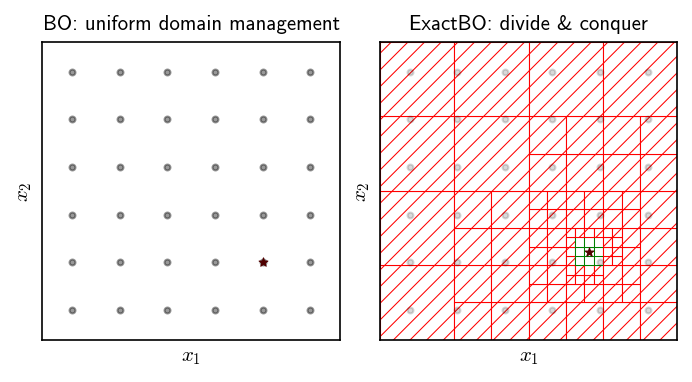

In [62]:
# Matplotlib figure for BO vs ExactBO (1x2), CM Sans, 10pt, 4.5x3.5 in
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# --- typography & style ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Set global hatch linewidth
plt.rcParams['hatch.linewidth'] = 0.5

# LaTeX rendering optional (turn on if your env supports it)
# mpl.rcParams.update({
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{sfmath}\renewcommand{\familydefault}{\sfdefault}"
# })

aggiemaroon = np.array([[80/255, 0, 0]])

fig, axs = plt.subplots(1, 2, figsize=(4.5, 3.5), constrained_layout=True)

# Common axis setup
for ax in axs:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

# --- Left: BO grid with best next point ---
ax = axs[0]
ax.set_title("BO: uniform domain management")

# grid points
gx = np.linspace(0.1, 0.9, 6)
gy = np.linspace(0.1, 0.9, 6)
X, Y = np.meshgrid(gx, gy)
ax.scatter(X, Y, s=8, c="black", alpha=0.4)

# best next point (star)
best_pt_BO = (0.74, 0.26)
ax.scatter(*best_pt_BO, s=20, marker="*", c=aggiemaroon, edgecolor=aggiemaroon, linewidth=0.5, zorder=5)

# --- Right: ExactBO divide & conquer (recursive tiling) ---
ax = axs[1]
ax.set_title("ExactBO: divide & conquer")

best_pt = (0.7, 0.3)
active_color = (0.0, 0.5, 0.0)

def subdivide(x, y, w, h, depth, max_depth, focus_pt, focus_radius):
    """Recursive quadtree subdivision."""
    cx = x + w / 2
    cy = y + h / 2
    dist = ((cx - focus_pt[0])**2 + (cy - focus_pt[1])**2) ** 0.5

    # Decide whether to subdivide further
    if depth < max_depth and dist < focus_radius * (2 ** (max_depth - depth)):
        # split into 4
        hw, hh = w / 2, h / 2
        subdivide(x,     y,     hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x+hw,  y,     hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x,     y+hh,  hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x+hw,  y+hh,  hw, hh, depth+1, max_depth, focus_pt, focus_radius)
    else:
        # leaf tile
        is_active = (dist < focus_radius)
        if is_active:
            ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                                   edgecolor=active_color, linewidth=0.5))
        else:
            ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                                   edgecolor="red", linewidth=0.5))
            ax.add_patch(Rectangle((x, y), w, h, facecolor="none",
                                   edgecolor="red", linewidth=0.5, hatch="///"))

# Parameters for the recursive look
subdivide(0.0, 0.0, 1.0, 1.0, depth=0, max_depth=5, focus_pt=best_pt, focus_radius=0.05)

# best point (same star)
best_pt_eBO = (0.703, 0.294)
ax.scatter(X, Y, s=8, c="black", alpha=0.15)
ax.scatter(*best_pt_eBO, s=20, marker="*", c=aggiemaroon, edgecolor=aggiemaroon, linewidth=0.5, zorder=5)

plt.show()
fig.savefig("Figures/bo_vs_exactbo.png", dpi=300, bbox_inches="tight")
fig.savefig("Figures/bo_vs_exactbo_transparent.png", dpi=300, bbox_inches="tight", transparent=True)